In [ ]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import scipy.stats as sps

<Axes: xlabel='dtime'>

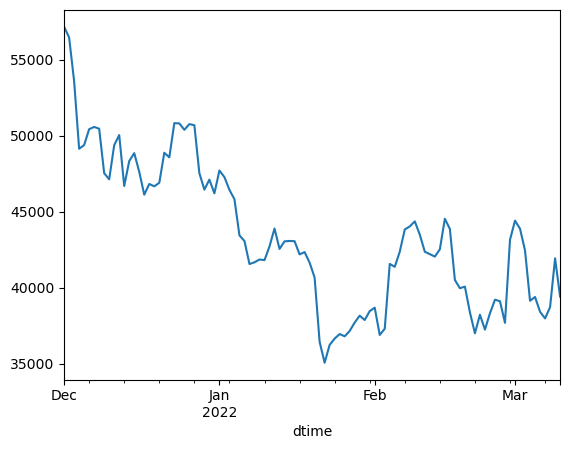

In [10]:
PAIR = 'BTC_USDT'
TIMEFRAME = '1d'

EXCHANGE = 'binance'

odf = pd.read_json(f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{EXCHANGE}/{PAIR}-{TIMEFRAME}.json'
# exchange = 'kucoin'
# odf = pd.read_json(f'../../freq-user-data/data/{exchange}/futures/{pair}-{timeframe}-futures.json'
).dropna().set_axis(['timestamp', 'open', 'high', 'low', 'close', 'volume'], axis=1
).assign(dtime=lambda x: pd.to_datetime(x['timestamp'], unit='ms', utc=False)
).drop('timestamp', axis=1
).set_index('dtime')#.sort_index()

ws = 700
ww = 100
y = odf.iloc[ws:ws+ww].close
y.plot()

In [15]:
dp = sm.datasets.get_rdataset("Duncan", "carData")
Y = dp.data['income']
X = dp.data['education']
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
results.params

const        10.603498
education     0.594859
dtype: float64

In [23]:
df = dp.data[['income', 'education']].reset_index()
df.drop(['rownames'],axis=1).to_csv('duncan.csv')

In [36]:
xol = df[['education']].copy().assign(intcpt=1)[['intcpt', 'education']]
xx = np.dot(xol.T, xol)
np.linalg.inv(xx)

array([[ 9.30974511e-02, -1.34857729e-03],
       [-1.34857729e-03,  2.56600331e-05]])